In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

***data importing***

In [4]:
print("--- Loading Datasets ---")
train = pd.read_csv('/content/drive/MyDrive/TAHMO Incoming Solar Radiation Prediction Challenge/Train.csv')
test = pd.read_csv('/content/drive/MyDrive/TAHMO Incoming Solar Radiation Prediction Challenge/Test.csv')
tropomi = pd.read_csv('/content/drive/MyDrive/TAHMO Incoming Solar Radiation Prediction Challenge/TROPOMI_Cloud_Fraction_TAHMO.csv')

--- Loading Datasets ---


In [5]:
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"TROPOMI shape: {tropomi.shape}")

print("\nTrain Data Head:")
display(train.head(3))

Train shape: (642175, 13)
Test shape: (683353, 12)
TROPOMI shape: (385, 3)

Train Data Head:


,ID,timestamp,precipitation (mm),radiation (W/m2),relativehumidity (-),temperature (degrees Celsius),station,station_name,country,installation_height,elevation,latitude,longitude
0,cd7ebf43_2018-01_VAH5X7,2018-01-20 08:15:00,0.0,224.0,0.319,17.3,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941
1,cd7ebf43_2018-01_YWVE4N,2018-01-20 08:30:00,0.0,272.0,0.309,18.0,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941
2,cd7ebf43_2018-01_1UZFA5,2018-01-20 08:45:00,0.0,328.0,0.303,18.9,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941


TROPOMI DUPLICATE VERIFICATION


In [6]:
print("--- Verifying TROPOMI Duplicates ---")
tropomi.rename(columns={'station_id': 'station'}, inplace=True)
tropomi['date'] = pd.to_datetime(tropomi['date']).dt.date.astype(str)

# Find exact duplicates for the same station on the same day
duplicates = tropomi[tropomi.duplicated(subset=['station', 'date'], keep=False)].sort_values(by=['station', 'date'])
print(f"Number of duplicate rows found: {len(duplicates)}")

if len(duplicates) > 0:
    print("\nSample of duplicated overpasses (Notice different cloud_fraction for same day):")
    display(duplicates.head(4))

# Fix duplicates by taking the mean (as done in the pipeline)
tropomi_clean = tropomi.groupby(['station', 'date'], as_index=False)['cloud_fraction'].mean()
print(f"\nTROPOMI shape after averaging duplicates: {tropomi_clean.shape}")


--- Verifying TROPOMI Duplicates ---
Number of duplicate rows found: 10

Sample of duplicated overpasses (Notice different cloud_fraction for same day):


,station,date,cloud_fraction
26,TA00349,2018-07-25,0.077124
27,TA00349,2018-07-25,0.083785
62,TA00349,2018-08-10,0.242612
63,TA00349,2018-08-10,0.133062



TROPOMI shape after averaging duplicates: (380, 3)


TRPORAL FEATURE EXTRACTION

In [7]:
print("--- Extracting Datetime and Cyclic Features ---")

def extract_temporal(df):
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['date'] = df['timestamp'].dt.date.astype(str)
    df['hour'] = df['timestamp'].dt.hour
    df['minute'] = df['timestamp'].dt.minute

    # Cyclic time features (0-24 hours mapped to a circle)
    time_in_hours = df['hour'] + df['minute'] / 60.0
    df['hour_sin'] = np.sin(2 * np.pi * time_in_hours / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * time_in_hours / 24.0)
    return df

train_time = extract_temporal(train.copy())
test_time = extract_temporal(test.copy())

print("Temporal features added successfully.")
display(train_time[['timestamp', 'hour', 'minute', 'hour_sin', 'hour_cos']].head(5))

--- Extracting Datetime and Cyclic Features ---
Temporal features added successfully.


,timestamp,hour,minute,hour_sin,hour_cos
0,2018-01-20 08:15:00,8,15,0.831470,-0.555570
1,2018-01-20 08:30:00,8,30,0.793353,-0.608761
2,2018-01-20 08:45:00,8,45,0.751840,-0.659346
3,2018-01-20 09:00:00,9,0,0.707107,-0.707107
4,2018-01-20 09:15:00,9,15,0.659346,-0.751840


SPATIO TEMPORAL ALIGNMENT (MERGING AND FILLING)

In [8]:
print("--- Simulating Spatio-Temporal Alignment ---")
# Merge daily TROPOMI onto 15-minute sensor data
train_merged = train_time.merge(tropomi_clean, on=['station', 'date'], how='left')

# Check missing values BEFORE filling
missing_before = train_merged['cloud_fraction'].isna().sum()
total_rows = len(train_merged)
print(f"Missing 'cloud_fraction' BEFORE interpolation: {missing_before} / {total_rows} ({missing_before/total_rows*100:.1f}%)")

# Apply forward fill and backward fill per station
train_merged['cloud_fraction'] = train_merged.groupby('station')['cloud_fraction'].ffill().bfill().fillna(0)

# Check missing values AFTER filling
missing_after = train_merged['cloud_fraction'].isna().sum()
print(f"Missing 'cloud_fraction' AFTER interpolation: {missing_after} / {total_rows} ({missing_after/total_rows*100:.1f}%)")

--- Simulating Spatio-Temporal Alignment ---
Missing 'cloud_fraction' BEFORE interpolation: 629983 / 642175 (98.1%)
Missing 'cloud_fraction' AFTER interpolation: 0 / 642175 (0.0%)


VISUALIZATION OF CLOUD FRACTION FILLING  FOR SINGLE STATION

--- Visualizing Cloud Fraction Filling for a Single Station ---


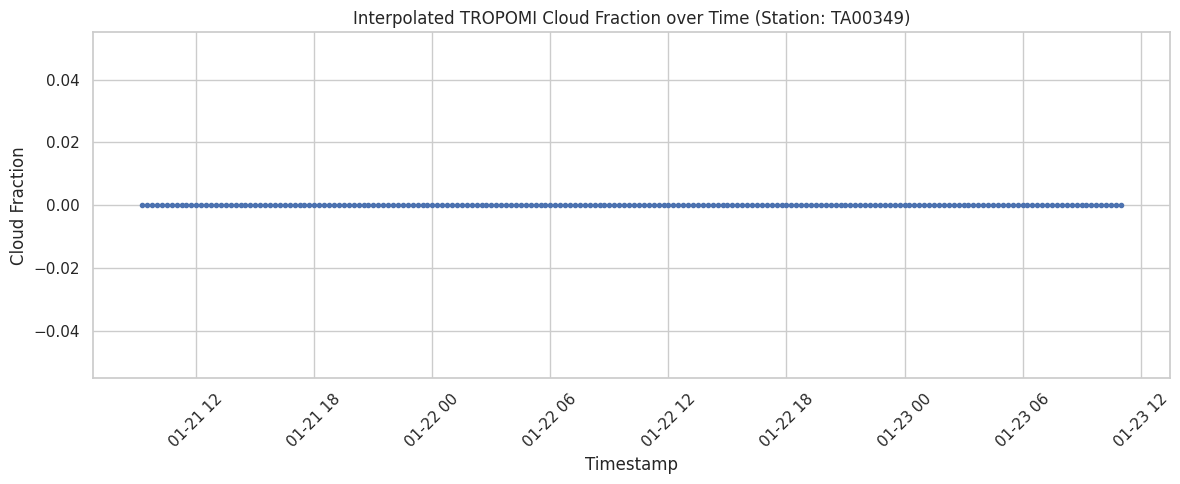

In [9]:
print("--- Visualizing Cloud Fraction Filling for a Single Station ---")
# Pick a random station to visualize how the daily value was stretched across 15-min intervals
sample_station = train_merged['station'].unique()[0]
sample_data = train_merged[train_merged['station'] == sample_station].iloc[100:300] # Plot 200 consecutive timestamps

plt.figure(figsize=(12, 5))
plt.plot(sample_data['timestamp'], sample_data['cloud_fraction'], marker='o', linestyle='-', color='b', markersize=3)
plt.title(f'Interpolated TROPOMI Cloud Fraction over Time (Station: {sample_station})')
plt.xlabel('Timestamp')
plt.ylabel('Cloud Fraction')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

VERIFYING ROLLING WINDOW (LOCALIZED COVARIATES)

In [10]:
print("--- Calculating and Verifying Rolling Windows ---")
train_sorted = train_merged.sort_values(by=['station', 'timestamp']).reset_index(drop=True)

# Calculate rolling 1-hour (4 periods) and 3-hour (12 periods) means for temperature and humidity
train_sorted['rh_roll1'] = train_sorted.groupby('station')['relativehumidity (-)'].transform(lambda x: x.rolling(4, min_periods=1).mean())
train_sorted['rh_roll3'] = train_sorted.groupby('station')['relativehumidity (-)'].transform(lambda x: x.rolling(12, min_periods=1).mean())
train_sorted['temp_roll1'] = train_sorted.groupby('station')['temperature (degrees Celsius)'].transform(lambda x: x.rolling(4, min_periods=1).mean())
train_sorted['temp_roll3'] = train_sorted.groupby('station')['temperature (degrees Celsius)'].transform(lambda x: x.rolling(12, min_periods=1).mean())

# Verify it mathematically on a small slice
verify_slice = train_sorted[['station', 'timestamp', 'temperature (degrees Celsius)', 'temp_roll1', 'temp_roll3']].head(6)
display(verify_slice)
print("Notice how 'temp_roll1' acts as a cumulative moving average for the first 4 rows, then becomes a sliding window.")


--- Calculating and Verifying Rolling Windows ---


,station,timestamp,temperature (degrees Celsius),temp_roll1,temp_roll3
0,TA00078,2016-01-11 10:30:00,20.4,20.400000,20.400000
1,TA00078,2016-01-11 10:45:00,20.5,20.450000,20.450000
2,TA00078,2016-01-11 11:00:00,20.4,20.433333,20.433333
3,TA00078,2016-01-11 11:15:00,20.5,20.450000,20.450000
4,TA00078,2016-01-11 11:30:00,19.7,20.275000,20.300000
5,TA00078,2016-01-11 11:45:00,20.3,20.225000,20.300000


Notice how 'temp_roll1' acts as a cumulative moving average for the first 4 rows, then becomes a sliding window.


TARGET VARIABLE (RADIATION)

--- Target Variable: Radiation Analysis ---


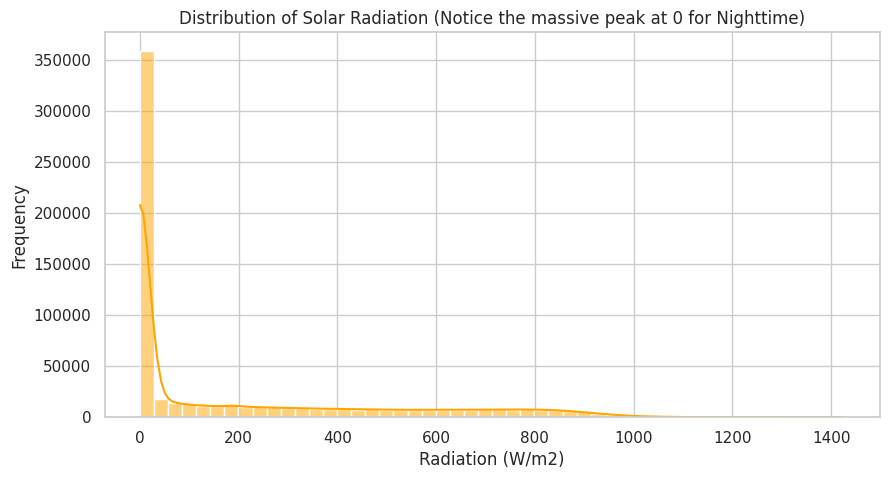

In [11]:
print("--- Target Variable: Radiation Analysis ---")
plt.figure(figsize=(10, 5))
sns.histplot(train_sorted['radiation (W/m2)'], bins=50, kde=True, color='orange')
plt.title('Distribution of Solar Radiation (Notice the massive peak at 0 for Nighttime)')
plt.xlabel('Radiation (W/m2)')
plt.ylabel('Frequency')
plt.show()

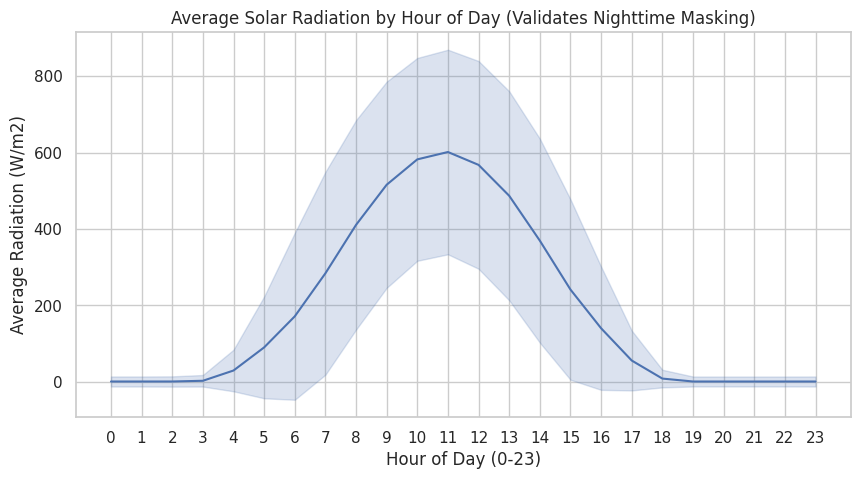

This explicitly verifies why we apply the strict nighttime mask (setting predictions to 0 before 05:00 and after 19:00) in the main pipeline.


In [12]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=train_sorted, x='hour', y='radiation (W/m2)', errorbar='sd')
plt.title('Average Solar Radiation by Hour of Day (Validates Nighttime Masking)')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Radiation (W/m2)')
plt.xticks(range(0, 24))
plt.show()
print("This explicitly verifies why we apply the strict nighttime mask (setting predictions to 0 before 05:00 and after 19:00) in the main pipeline.")

Feature Correlation Analysis

--- Feature Correlation Heatmap ---


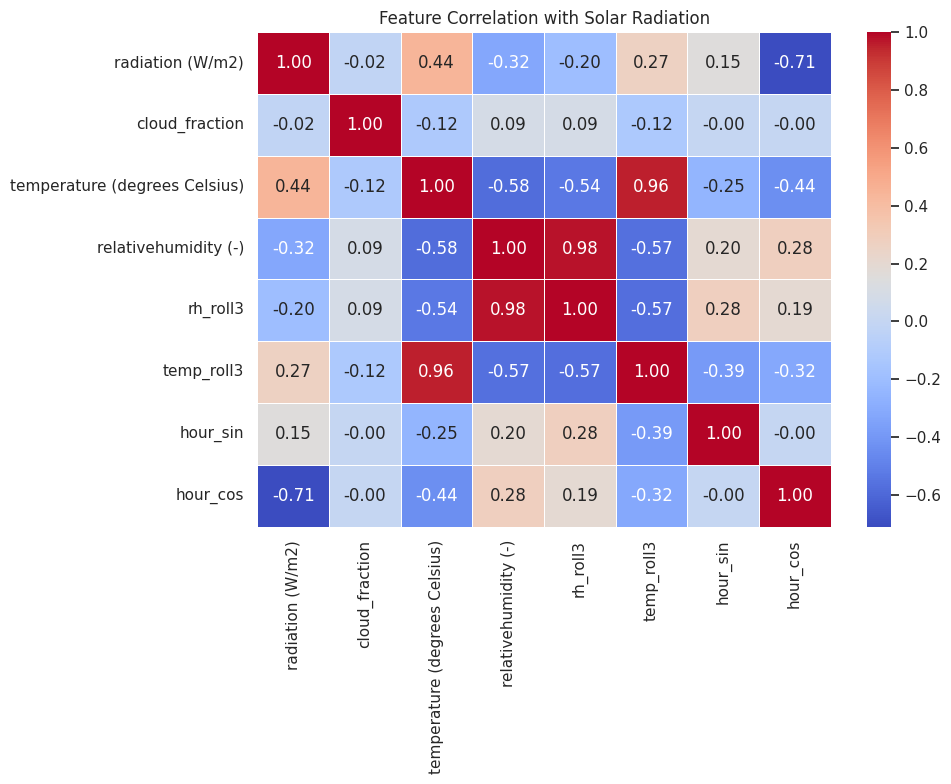

Look for strong negative correlations between 'cloud_fraction' and radiation, and strong positive correlations with 'temperature'.


In [13]:
print("--- Feature Correlation Heatmap ---")
# Select features to evaluate
correlation_features = [
    'radiation (W/m2)', 'cloud_fraction', 'temperature (degrees Celsius)',
    'relativehumidity (-)', 'rh_roll3', 'temp_roll3', 'hour_sin', 'hour_cos'
]

plt.figure(figsize=(10, 8))
corr_matrix = train_sorted[correlation_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation with Solar Radiation')
plt.tight_layout()
plt.show()
print("Look for strong negative correlations between 'cloud_fraction' and radiation, and strong positive correlations with 'temperature'.")


Time-Stratified Validation Split (Chronological)

In [17]:
print("--- Creating Time-Stratified Split ---")

# FIX: Ensure 'dayofyear' and 'month' exist
train_sorted['timestamp'] = pd.to_datetime(train_sorted['timestamp'])
train_sorted['dayofyear'] = train_sorted['timestamp'].dt.dayofyear
train_sorted['month'] = train_sorted['timestamp'].dt.month

# The competition organizers ALREADY split Train (odd months) and Test (even months).
# Since the Train dataset ONLY contains odd months (1, 3, 5, 7, 9, 11),
# splitting by even months here results in an EMPTY validation set.
# Instead, let's use the last available month (November / Month 11) as our local validation set.
train_mask = train_sorted['month'] < 11
val_mask = train_sorted['month'] == 11

# Separate features and target
features = [
    'precipitation (mm)', 'relativehumidity (-)', 'temperature (degrees Celsius)',
    'hour_sin', 'hour_cos', 'dayofyear', 'cloud_fraction',
    'rh_roll1', 'rh_roll3', 'temp_roll1', 'temp_roll3'
]
target = 'radiation (W/m2)'

X_train_strat = train_sorted.loc[train_mask, features]
y_train_strat = train_sorted.loc[train_mask, target]
X_val_strat = train_sorted.loc[val_mask, features]
y_val_strat = train_sorted.loc[val_mask, target]

print(f"Training set shape:   {X_train_strat.shape}")
print(f"Validation set shape: {X_val_strat.shape}")



--- Creating Time-Stratified Split ---
Training set shape:   (527094, 11)
Validation set shape: (115081, 11)


# ** Teacher Model Training & Feature Importance**

--- Training the 'Teacher' Model on Time-Stratified Data ---
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027100 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2142
[LightGBM] [Info] Number of data points in the train set: 527094, number of used features: 11
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 190.259477
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[38]	valid_0's l2: 21314.7	valid_0's custom_rmse_mbe: 80.7168

--- Visualizing Feature Importance ---


<Figure size 1000x600 with 0 Axes>

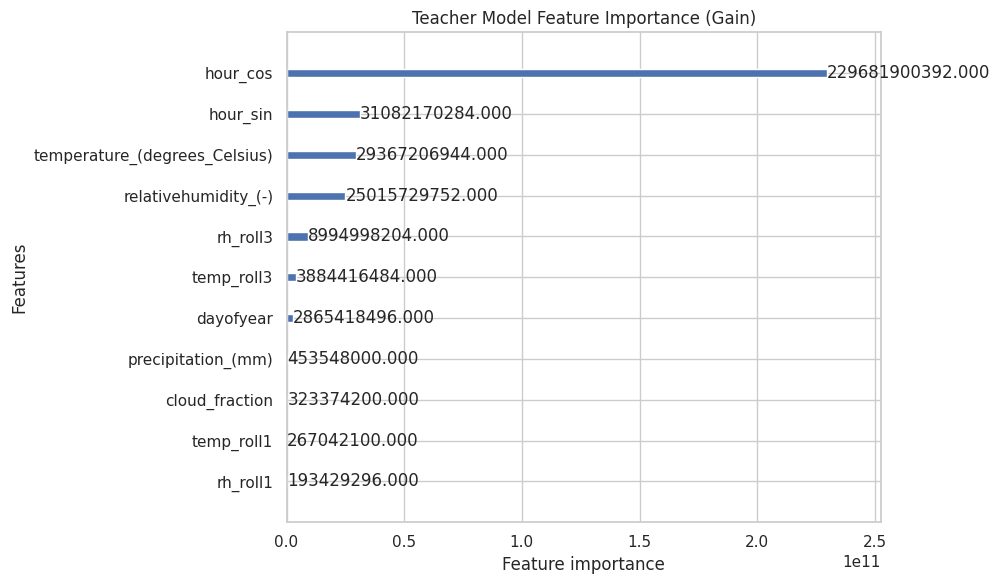

In [18]:

import lightgbm as lgb
from sklearn.metrics import mean_squared_error

print("--- Training the 'Teacher' Model on Time-Stratified Data ---")

# Define the custom objective function logic for evaluation
def custom_eval(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mbe = np.mean(y_pred - y_true)
    combined_loss = (0.5 * rmse) + (0.5 * np.abs(mbe))
    return 'custom_rmse_mbe', combined_loss, False

# Train the model
teacher_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

teacher_model.fit(
    X_train_strat, y_train_strat,
    eval_set=[(X_val_strat, y_val_strat)],
    eval_metric=custom_eval,
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=True)]
)

print("\n--- Visualizing Feature Importance ---")
plt.figure(figsize=(10, 6))
lgb.plot_importance(teacher_model, max_num_features=15, importance_type='gain',
                    title="Teacher Model Feature Importance (Gain)", figsize=(10,6))
plt.tight_layout()
plt.show()



Validation Performance & Residual Analysis


--- Validation Performance Analysis ---
Validation RMSE: 145.76 W/m2
Validation MBE:  2.47 W/m2


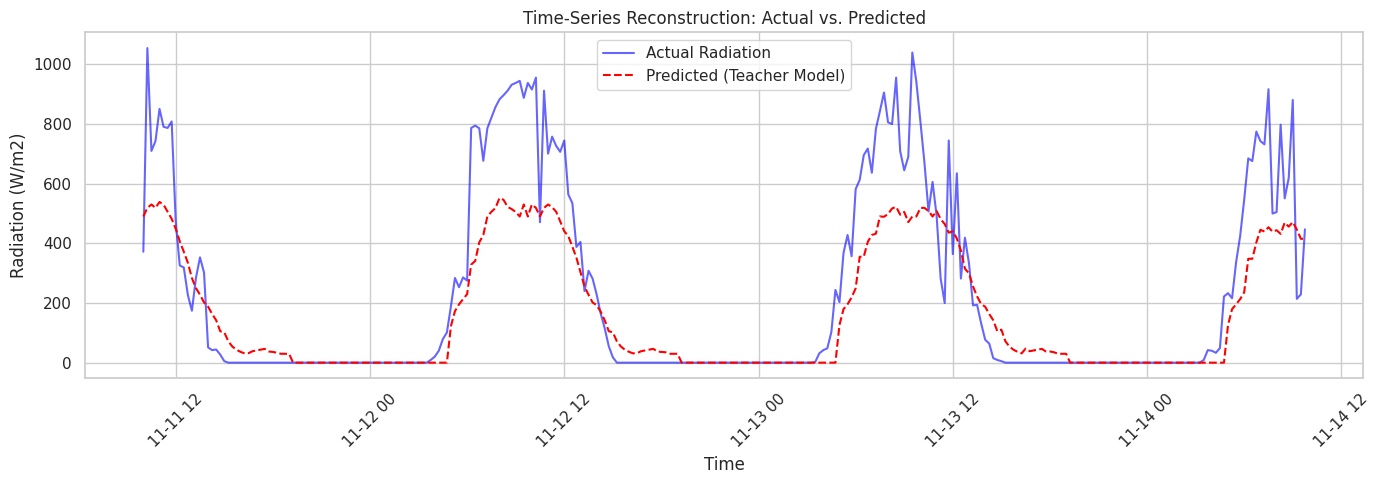

In [19]:
======================
print("--- Validation Performance Analysis ---")
# Predict on the validation months
val_preds = teacher_model.predict(X_val_strat)

# Apply physics-based nighttime mask to validation predictions
val_hours = train_sorted.loc[val_mask, 'hour'] + train_sorted.loc[val_mask, 'minute'] / 60.0
night_mask = (val_hours < 5.0) | (val_hours > 19.0)
val_preds = np.clip(val_preds, 0, None)
val_preds[night_mask] = 0.0

# Calculate final metrics
final_rmse = np.sqrt(mean_squared_error(y_val_strat, val_preds))
final_mbe = np.mean(val_preds - y_val_strat)

print(f"Validation RMSE: {final_rmse:.2f} W/m2")
print(f"Validation MBE:  {final_mbe:.2f} W/m2")

# Plot Actual vs Predicted for a random 3-day window in the validation set
sample_val = train_sorted[val_mask].iloc[1000:1288] # Roughly 3 days of 15-min intervals
sample_preds = val_preds[1000:1288]

plt.figure(figsize=(14, 5))
plt.plot(sample_val['timestamp'], sample_val['radiation (W/m2)'], label='Actual Radiation', color='blue', alpha=0.6)
plt.plot(sample_val['timestamp'], sample_preds, label='Predicted (Teacher Model)', color='red', linestyle='--')
plt.title('Time-Series Reconstruction: Actual vs. Predicted')
plt.xlabel('Time')
plt.ylabel('Radiation (W/m2)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Test Set Inference & Submission Preparation**

In [24]:
print("--- Preparing Test Data and Generating Final Submission ---")

# 1. Merge TROPOMI and interpolate for the test set
test_merged = test_time.merge(tropomi_clean, on=['station', 'date'], how='left')
test_merged['cloud_fraction'] = test_merged.groupby('station')['cloud_fraction'].ffill().bfill().fillna(0)

# 2. Sort and calculate rolling windows for test set
test_sorted = test_merged.sort_values(by=['station', 'timestamp']).reset_index(drop=True)
test_sorted['rh_roll1'] = test_sorted.groupby('station')['relativehumidity (-)'].transform(lambda x: x.rolling(4, min_periods=1).mean())
test_sorted['rh_roll3'] = test_sorted.groupby('station')['relativehumidity (-)'].transform(lambda x: x.rolling(12, min_periods=1).mean())
test_sorted['temp_roll1'] = test_sorted.groupby('station')['temperature (degrees Celsius)'].transform(lambda x: x.rolling(4, min_periods=1).mean())
test_sorted['temp_roll3'] = test_sorted.groupby('station')['temperature (degrees Celsius)'].transform(lambda x: x.rolling(12, min_periods=1).mean())

# 3. Add 'dayofyear'
test_sorted['timestamp'] = pd.to_datetime(test_sorted['timestamp'])
test_sorted['dayofyear'] = test_sorted['timestamp'].dt.dayofyear

# 4. Extract features
X_test_final = test_sorted[features]

# 5. Predict using the trained Teacher model
print("Generating predictions on the unobserved Test set...")
test_preds = teacher_model.predict(X_test_final)

# 6. Apply physics-based nighttime mask
test_hours = test_sorted['hour'] + test_sorted['minute'] / 60.0
test_night_mask = (test_hours < 5.0) | (test_hours > 19.0)
test_preds = np.clip(test_preds, 0, None)
test_preds[test_night_mask] = 0.0

# 7. Format submission
print("Formatting submission file...")
sample_sub = pd.read_csv('/content/drive/MyDrive/TAHMO Incoming Solar Radiation Prediction Challenge/Test.csv')

submission_df = pd.DataFrame({
    'ID': test_sorted['ID'],
    'TargetMBE': test_preds,
    'TargetRMSE': test_preds
})

# Ensure chronological/exact order matches SampleSubmission
final_submission = sample_sub[['ID']].merge(submission_df, on='ID', how='left')

# Save to CSV
final_submission.to_csv('final_submission6.csv', index=False)
print("Success! 'final_submission.csv' generated and ready for Zindi.")
display(final_submission.head())

--- Preparing Test Data and Generating Final Submission ---
Generating predictions on the unobserved Test set...
Formatting submission file...
Success! 'final_submission.csv' generated and ready for Zindi.


,ID,TargetMBE,TargetRMSE
0,e1ca667d_2017-02_6DN3R0,0.0,0.0
1,e1ca667d_2017-02_CA6DZ7,0.0,0.0
2,e1ca667d_2017-02_3UJPYF,0.0,0.0
3,e1ca667d_2017-02_PKCTGW,0.0,0.0
4,e1ca667d_2017-02_7GFGDR,0.0,0.0
